In [3]:
# %matplotlib widget

In [4]:
from py_mods.src.SCF.CSRHF import CS_RHF
from py_mods.src.SCF.CSUHF import CS_UHF
from py_mods.src.SCF.external import RHF_context_from_pyscf, UHF_context_from_pyscf
from py_mods.src.MP2.CSMP2 import CS_MP2

import matplotlib.pyplot as plt

In [5]:
pyscf_args = {"atom": "la 0 0 0;", "spin": 1, "charge": 0, "basis":"ano-rcc"}

In [6]:
la_cxt = UHF_context_from_pyscf(**pyscf_args)
la_cxt.verbose = True
la_cxt.p_guess = "RHF"
la_cxt.guess_max_iter = 100
la_cxt.acc_hist_size =  8
la_cxt.break_symm = True
la_cxt.acc_iteration_start = 14
la_cxt.threshold = 1e-10
la_cxt.max_iter = 200

In [7]:
la_scf_results = CS_UHF(la_cxt)



Alpha occupation:  [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Beta  occupation:  [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
--------------------------------------------------------------------------------------------------------------------------------
|   Iter     |                   E_iter                      |                   Delta_e                   |      norm(e_i)      |
----------------------------



Final UHF Energy: (-7745.030143933089+0j)


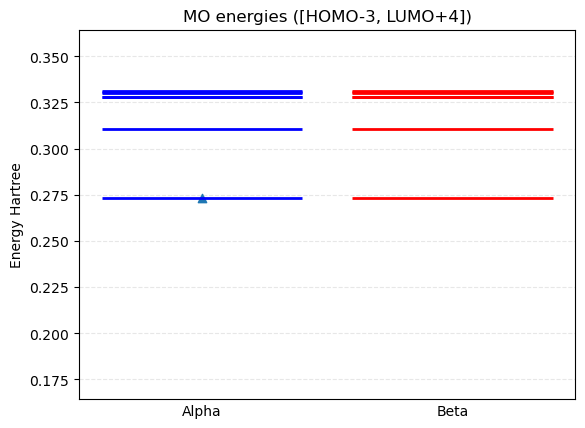

In [8]:
from py_mods.src.SCF.plot_utilities import plot_UHF_MO_energies
print("\n\nFinal UHF Energy:", la_scf_results.E_UHF)  # 4338 iterations


plot_UHF_MO_energies(la_scf_results, ylim=["HOMO-3", "LUMO+4"])

In [9]:
from pyscf import gto, scf

mol = gto.M(**pyscf_args)
pyscf_uhf = scf.UHF(mol)
pyscf_uhf.verbose = 3
pyscf_uhf.max_cycle = 500

pyscf_uhf.kernel()

e_pyscf = pyscf_uhf.energy_elec()[0]

converged SCF energy = -7853.91593120065  <S^2> = 0.77063221  2S+1 = 2.0205269


In [10]:
print(f"Energy difference: {la_scf_results.E_UHF.real - e_pyscf}")

Energy difference: 108.88578726755804
